# Linear Regression Model — Predicting Battery Health

**Goal:** predict `current_battery_health_percent` (a continuous value, 10–100%) from device usage and charging-behavior data, using multiple linear regression.

**Approach:**
- Train on a random **90%** of devices, test on the held-out **10%**
- Not every column in `clean_data.csv` belongs in the model — Step 2 below walks through what's kept, what's dropped, and why
- End with the fitted regression equation and an honest read of how well it performs on unseen data

This is the first of three planned models for this project (linear regression → time-series analysis → XGBoost), so metrics here are also meant as a **baseline** for comparison later on.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# palette (kept consistent across the project's charts)
BLUE   = "#2a78d6"   # primary series / magnitude
ORANGE = "#eb6834"   # reference / secondary
RED    = "#e34948"   # negative pole (diverging)
GRAY   = "#898781"   # muted axis/grid
GRID   = "#e1e0d9"   # hairline gridline

data = pd.read_csv("clean_data.csv")
target = "current_battery_health_percent"

print("Rows, columns:", data.shape)
data.head()

Rows, columns: (5000, 13)


,Device_ID,device_age_months,battery_capacity_mah,avg_charging_cycles_per_week,fast_charging_usage_percent,overnight_charging_freq_per_week,background_app_usage_level,signal_strength_avg,video_streaming_hours_per_week,gaming_hours_per_week,avg_screen_on_hours_per_day,current_battery_health_percent,recommended_action
0,207dd94c-0430-43aa-b388-4893447e628e,38,4500,11.4,90.8,7,Medium,Poor,14.0,7.9,7.1,32.8,Change Phone
1,3f4d1d33-ba89-4814-a168-7b4cc75be26b,28,3000,10.3,60.6,2,Medium,Good,11.0,8.6,6.8,50.3,Replace Battery
2,b4adca05-564f-4b70-ab69-e8d66e656463,14,3000,11.2,29.3,4,Medium,Good,10.3,0.3,7.2,66.1,Replace Battery
3,4147e039-31b7-480a-bbc9-03cd0f66e9f1,42,3000,8.3,62.5,0,Medium,Good,4.9,1.9,5.5,46.8,Change Phone
4,3f9b0fb7-73c2-4ab7-8e30-7b492097a3f5,7,3000,11.6,85.4,6,High,Good,9.3,7.9,7.6,67.2,Replace Battery


## Step 1 — The Target Variable

`current_battery_health_percent` is the only sensible regression target in this dataset — it's the one continuous, directly-measured "how healthy is the battery right now" value (range: **10–100%**, mean ≈ 62.6%, std ≈ 17.7).

The other candidate output, `recommended_action`, is categorical (`Keep Using` / `Replace Battery` / `Change Phone`) — that's a classification problem, not a regression one, and it turns out to be derived from this same target anyway (see Step 2).

In [2]:
print(data[target].describe().round(2))

count    5000.00
mean       62.60
std        17.72
min        10.00
25%        50.20
50%        64.10
75%        76.90
max       100.00
Name: current_battery_health_percent, dtype: float64


## Step 2 — Feature Selection: What's In, What's Out (and Why)

`clean_data.csv` has 12 candidate columns besides the target. Four of them are **excluded** — two because they structurally don't belong in a regression, two because the data shows they carry no usable signal. The remaining **eight are numeric, plausible drivers of battery wear**, and are all kept.

### Excluded

| Parameter | Why it's excluded |
|---|---|
| `Device_ID` | A random UUID, unique per row (5,000 values for 5,000 rows). It isn't a measurable attribute — it's a label. One-hot encoding it would add one column per device, which the model would just use to memorize each row (perfect train fit, meaningless for any device it hasn't already seen). It literally **cannot fit** into a regression in any useful way. |
| `recommended_action` | **Data leakage.** It's a bucketed re-statement of the target itself, not an independent input — confirmed below. |
| `background_app_usage_level` | Categorical (Low/Medium/High), but correlation with the target is essentially zero (r ≈ 0.01) and group means are nearly identical (62.3–63.1%). It's encodable, it just **doesn't explain anything** here. |
| `signal_strength_avg` | Same story: r ≈ 0.01, group means 62.1–62.7%. Conceptually it's more about real-time signal-hunting power draw than long-term capacity fade, and the data agrees there's no relationship to model. |

### Included (8 features)

| Parameter | Rationale |
|---|---|
| `device_age_months` | Batteries chemically degrade with age — the single strongest expected driver. |
| `battery_capacity_mah` | Device spec / battery generation — included as a baseline control even though its own effect turns out to be weak. |
| `avg_charging_cycles_per_week` | More charge cycles = more chemical wear, a textbook degradation mechanism. |
| `fast_charging_usage_percent` | Fast charging generates more heat, which accelerates degradation. |
| `overnight_charging_freq_per_week` | Long trickle-charging at 100% is a known stressor on lithium-ion cells. |
| `video_streaming_hours_per_week` | Sustained discharge/heat from heavy usage. |
| `gaming_hours_per_week` | High current draw + heat — one of the more demanding usage patterns. |
| `avg_screen_on_hours_per_day` | General proxy for how hard the device (and battery) is used day to day. |

All eight are numeric already, so no encoding is needed.

In [3]:
features = [
    "device_age_months",
    "battery_capacity_mah",
    "avg_charging_cycles_per_week",
    "fast_charging_usage_percent",
    "overnight_charging_freq_per_week",
    "video_streaming_hours_per_week",
    "gaming_hours_per_week",
    "avg_screen_on_hours_per_day",
]

excluded = ["Device_ID", "recommended_action", "background_app_usage_level", "signal_strength_avg"]

# Confirm the data-leakage claim about recommended_action: does it map to
# non-overlapping ranges of the target?
print("recommended_action vs current_battery_health_percent (min/mean/max):")
print(data.groupby("recommended_action")[target].agg(["min", "mean", "max"]).round(1))

print("\nCorrelation of each included feature with the target:")
print(data[features + [target]].corr()[target].drop(target).sort_values().round(3))

recommended_action vs current_battery_health_percent (min/mean/max):
                     min  mean    max
recommended_action                   
Change Phone        10.0  38.4   49.9
Keep Using          75.0  82.8  100.0
Replace Battery     50.0  62.9   74.9

Correlation of each included feature with the target:
device_age_months                  -0.854
avg_charging_cycles_per_week       -0.410
avg_screen_on_hours_per_day        -0.399
overnight_charging_freq_per_week   -0.067
gaming_hours_per_week              -0.049
fast_charging_usage_percent        -0.033
battery_capacity_mah               -0.011
video_streaming_hours_per_week      0.018
Name: current_battery_health_percent, dtype: float64


The `recommended_action` ranges don't overlap at all (`Change Phone`: 10.0–49.9% → `Replace Battery`: 50.0–74.9% → `Keep Using`: 75.0–100%) — it's a rule applied *to* the target, not an independent measurement. Using it as a predictor would let the model cheat by decoding that rule instead of learning real degradation patterns, and it wouldn't be available at prediction time regardless (it's downstream of the number we're trying to predict).

## Step 3 — Multicollinearity Check

Before fitting, check whether any of the 8 kept features are redundant with each other (which would make individual coefficients unstable/misleading even if the overall model still predicts fine).

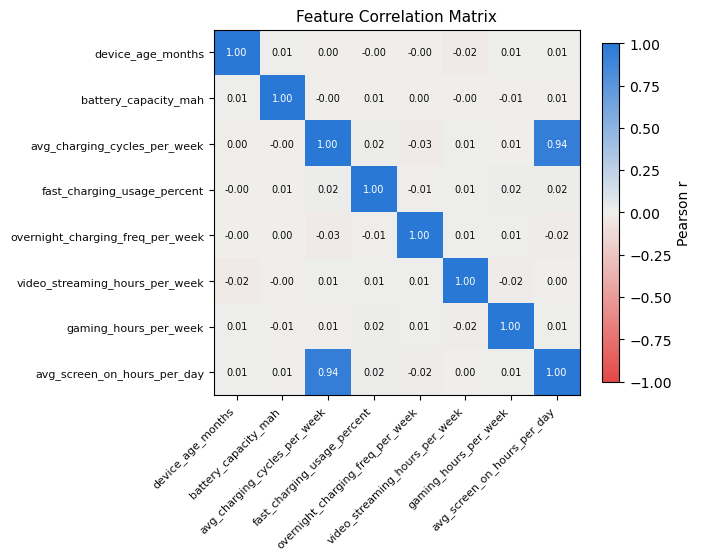

                         feature      VIF
     avg_screen_on_hours_per_day 9.300998
    avg_charging_cycles_per_week 9.300913
           gaming_hours_per_week 1.001788
  video_streaming_hours_per_week 1.001729
     fast_charging_usage_percent 1.001237
overnight_charging_freq_per_week 1.001216
               device_age_months 1.000971
            battery_capacity_mah 1.000599

In [4]:
corr_matrix = data[features].corr()

fig, ax = plt.subplots(figsize=(7, 6))
cmap = mcolors.LinearSegmentedColormap.from_list("diverging", [RED, "#f0efec", BLUE])
im = ax.imshow(corr_matrix, cmap=cmap, vmin=-1, vmax=1)

ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha="right", fontsize=8, color="#0b0b0b")
ax.set_yticklabels(features, fontsize=8, color="#0b0b0b")

for i in range(len(features)):
    for j in range(len(features)):
        val = corr_matrix.iloc[i, j]
        color = "white" if abs(val) > 0.55 else "#0b0b0b"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color=color)

ax.set_title("Feature Correlation Matrix", fontsize=11)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
plt.tight_layout()
plt.show()

# Variance Inflation Factor
X_vif = sm.add_constant(data[features])
vif = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
print(vif[vif["feature"] != "const"].sort_values("VIF", ascending=False).to_string(index=False))

`avg_charging_cycles_per_week` and `avg_screen_on_hours_per_day` are fairly correlated with each other (r = 0.94 — makes sense: more screen time tends to mean more charging). Their VIF (~9.3) sits just under the common rule-of-thumb danger threshold of 10, so both are kept for this baseline, but it's flagged as a real limitation — see the suggestions at the end. Every other feature is essentially independent (VIF ≈ 1).

## Step 4 — Train / Test Split (90% / 10%)

In [5]:
X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42
)

print(f"Training set: {X_train.shape[0]} devices ({X_train.shape[0] / len(data):.0%})")
print(f"Test set:     {X_test.shape[0]} devices ({X_test.shape[0] / len(data):.0%})")

Training set: 4500 devices (90%)
Test set:     500 devices (10%)


## Step 5 — Fit the Model

Fit with scikit-learn (for prediction / evaluation) and cross-check with statsmodels OLS on the same training data (for coefficient significance — standard errors, t-stats, p-values, confidence intervals).

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", round(model.intercept_, 4))
print("\nCoefficients:")
for f, c in zip(features, model.coef_):
    print(f"  {f:<35s} {c: .4f}")

Intercept: 113.424

Coefficients:
  device_age_months                   -1.0665
  battery_capacity_mah                -0.0001
  avg_charging_cycles_per_week        -1.9644
  fast_charging_usage_percent         -0.0226
  overnight_charging_freq_per_week    -0.6330
  video_streaming_hours_per_week      -0.0051
  gaming_hours_per_week               -0.2341
  avg_screen_on_hours_per_day         -0.6997


In [7]:
X_train_sm = sm.add_constant(X_train)
ols = sm.OLS(y_train, X_train_sm).fit()
print(ols.summary())

                                  OLS Regression Results                                  
Dep. Variable:     current_battery_health_percent   R-squared:                       0.905
Model:                                        OLS   Adj. R-squared:                  0.905
Method:                             Least Squares   F-statistic:                     5363.
Date:                            Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                                    11:34:34   Log-Likelihood:                -14026.
No. Observations:                            4500   AIC:                         2.807e+04
Df Residuals:                                4491   BIC:                         2.813e+04
Df Model:                                       8                                         
Covariance Type:                        nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025  

Two features come back statistically insignificant at the training stage: `battery_capacity_mah` (p = 0.327) and `video_streaming_hours_per_week` (p = 0.754). Their true effect on battery health can't be distinguished from zero given this data — see the trimmed-model comparison in the suggestions section.

## Step 6 — Evaluate on the Held-Out 10%

The test set was never touched during fitting — this is the honest read of how the model generalizes.

In [8]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

metrics = pd.DataFrame({
    "R²":  [r2_score(y_train, y_pred_train), r2_score(y_test, y_pred_test)],
    "RMSE": [np.sqrt(mean_squared_error(y_train, y_pred_train)), np.sqrt(mean_squared_error(y_test, y_pred_test))],
    "MAE":  [mean_absolute_error(y_train, y_pred_train), mean_absolute_error(y_test, y_pred_test)],
}, index=["Train (90%)", "Test (10%)"]).round(3)

print(metrics)

                R²   RMSE    MAE
Train (90%)  0.905  5.463  4.341
Test (10%)   0.898  5.568  4.389


Train and test scores are almost identical (R² ≈ 0.90 either way) — the model isn't overfitting, and it explains about 90% of the variance in battery health from these 8 features alone. On the held-out set, predictions are off by about **4.4 percentage points on average** (MAE), with a typical error (RMSE) of about **5.6 points**.

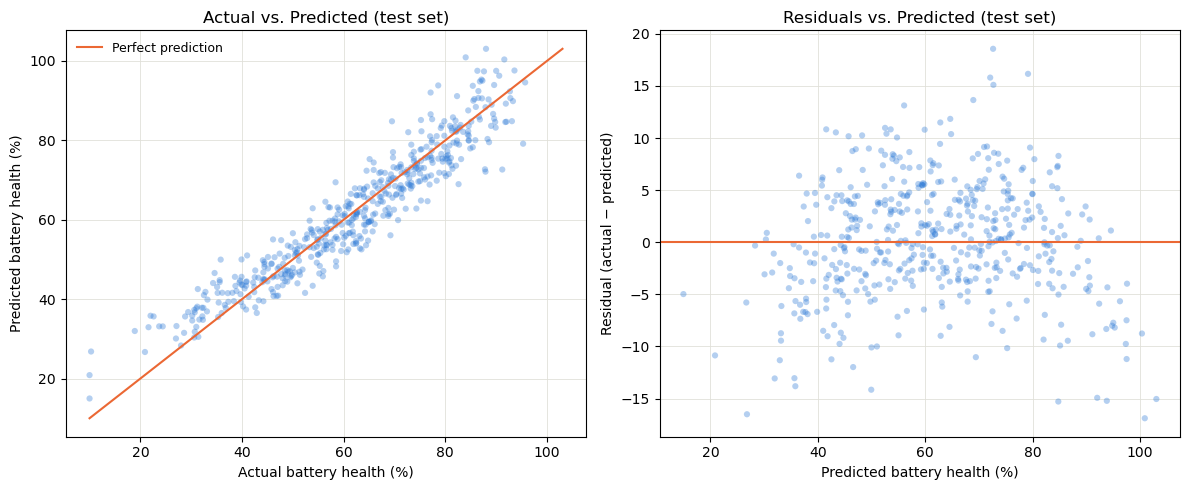

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_test, alpha=0.35, s=20, color=BLUE, edgecolor="none")
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, color=ORANGE, linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual battery health (%)")
axes[0].set_ylabel("Predicted battery health (%)")
axes[0].set_title("Actual vs. Predicted (test set)")
axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(color=GRID, linewidth=0.6)
axes[0].set_axisbelow(True)

# Residuals vs predicted
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.35, s=20, color=BLUE, edgecolor="none")
axes[1].axhline(0, color=ORANGE, linewidth=1.5)
axes[1].set_xlabel("Predicted battery health (%)")
axes[1].set_ylabel("Residual (actual − predicted)")
axes[1].set_title("Residuals vs. Predicted (test set)")
axes[1].grid(color=GRID, linewidth=0.6)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

Residuals scatter evenly around zero with no funnel or curve shape — the linear model's assumptions (constant error variance, no leftover nonlinearity) hold up reasonably well across the full range.

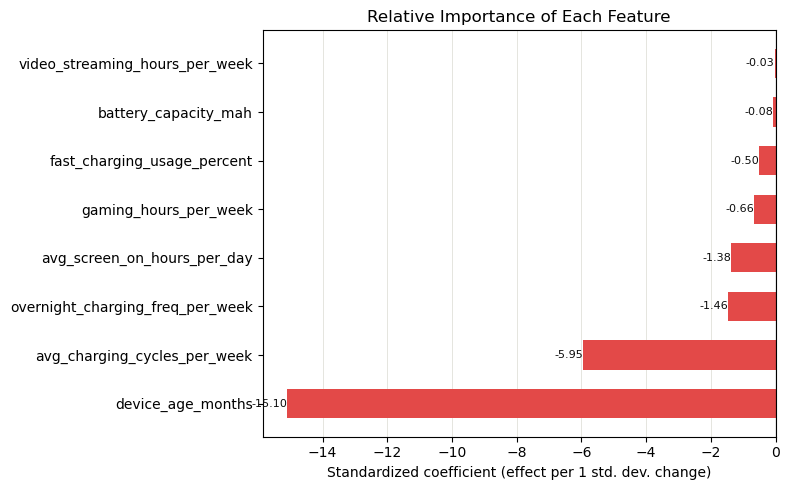

In [10]:
# Standardized coefficients (z-scored features) -- lets us compare relative
# importance on one common scale, since the raw coefficients above aren't
# comparable across features measured in different units (months vs. % vs. hours).
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=features)
model_scaled = LinearRegression().fit(X_train_scaled, y_train)

importance = pd.Series(model_scaled.coef_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = [RED if v < 0 else BLUE for v in importance]
bars = ax.barh(importance.index, importance.values, color=colors, height=0.6)
ax.axvline(0, color="#0b0b0b", linewidth=0.8)
ax.set_xlabel("Standardized coefficient (effect per 1 std. dev. change)")
ax.set_title("Relative Importance of Each Feature")
ax.grid(color=GRID, linewidth=0.6, axis="x")
ax.set_axisbelow(True)

for bar, val in zip(bars, importance.values):
    offset = 0.05 if val < 0 else -0.05
    ha = "right" if val < 0 else "left"
    ax.text(val + (0.15 if val < 0 else -0.15) * 0, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", ha="left" if val >= 0 else "right",
            fontsize=8, color="#0b0b0b")

plt.tight_layout()
plt.show()

On a like-for-like scale, `device_age_months` dominates by a wide margin — it drives roughly 3-4x more of the swing in predicted battery health than the next-largest factor (`avg_charging_cycles_per_week`). `battery_capacity_mah` and `video_streaming_hours_per_week` barely register, consistent with them being statistically insignificant in Step 5.

## Step 7 — Final Regression Formula

Fitted on the training 90% of devices:

$$
\begin{aligned}
\widehat{\text{battery\_health\_\%}} = \ & 113.424 \\
& - 1.0665 \times \text{device\_age\_months} \\
& - 0.0001 \times \text{battery\_capacity\_mah} \\
& - 1.9644 \times \text{avg\_charging\_cycles\_per\_week} \\
& - 0.0226 \times \text{fast\_charging\_usage\_percent} \\
& - 0.6330 \times \text{overnight\_charging\_freq\_per\_week} \\
& - 0.0051 \times \text{video\_streaming\_hours\_per\_week} \\
& - 0.2341 \times \text{gaming\_hours\_per\_week} \\
& - 0.6997 \times \text{avg\_screen\_on\_hours\_per\_day}
\end{aligned}
$$

**Reading it:** every included factor pushes battery health *down* as it increases — none of the 8 factors are associated with battery health *improving*, which matches physical intuition (there's no usage pattern here that should heal a battery). The intercept (113.42) is the model's baseline for a brand-new, unused device and isn't meaningful in isolation since no real device has all inputs at exactly zero.

**Caveat:** this is a straight line, so it isn't naturally bounded to 0–100%. For a brand-new device (age ≈ 0) with heavy inputs, or a very old device pushed further, the raw formula can technically predict outside that range — clip predictions to `[0, 100]` before presenting them.

In [11]:
def predict_battery_health(device_age_months, battery_capacity_mah, avg_charging_cycles_per_week,
                            fast_charging_usage_percent, overnight_charging_freq_per_week,
                            video_streaming_hours_per_week, gaming_hours_per_week,
                            avg_screen_on_hours_per_day):
    '''Predict current battery health (%) from the 8 model inputs, clipped to a valid 0-100 range.'''
    x = pd.DataFrame([{
        "device_age_months": device_age_months,
        "battery_capacity_mah": battery_capacity_mah,
        "avg_charging_cycles_per_week": avg_charging_cycles_per_week,
        "fast_charging_usage_percent": fast_charging_usage_percent,
        "overnight_charging_freq_per_week": overnight_charging_freq_per_week,
        "video_streaming_hours_per_week": video_streaming_hours_per_week,
        "gaming_hours_per_week": gaming_hours_per_week,
        "avg_screen_on_hours_per_day": avg_screen_on_hours_per_day,
    }])[features]
    pred = model.predict(x)[0]
    return float(np.clip(pred, 0, 100))

# Example: a 24-month-old device with moderate usage
predict_battery_health(
    device_age_months=24, battery_capacity_mah=4500, avg_charging_cycles_per_week=8.3,
    fast_charging_usage_percent=50, overnight_charging_freq_per_week=3,
    video_streaming_hours_per_week=10, gaming_hours_per_week=4, avg_screen_on_hours_per_day=5.5,
)

63.17805775430372

## Suggestions for a Cleaner, Easier-to-Understand Final Presentation

A few concrete additions worth considering before this goes in front of a wider audience (or gets compared against the time-series and XGBoost models):

1. **An executive-summary cell at the very top.** Most readers won't dig through diagnostics — a short "headline" block (R² = 0.90, typical error ≈ ±4–6 points, biggest driver = device age) up front would let a non-technical reader get the point in 10 seconds.

2. **A trimmed, simpler formula as the "presentation" version.** Dropping the two statistically insignificant features (`battery_capacity_mah`, `video_streaming_hours_per_week`) gives test R² = 0.8985 / RMSE = 5.56 — essentially identical to the full 8-feature model (R² = 0.8984 / RMSE = 5.57). A 6-term formula is meaningfully easier to read and explain than an 8-term one for basically zero accuracy cost. (Numbers confirmed — happy to swap this in as the headline formula if you'd rather present the simpler one.)

3. **Address the `avg_charging_cycles_per_week` ↔ `avg_screen_on_hours_per_day` collinearity (r = 0.94).** It didn't break anything here (VIF stayed just under 10), but it does mean those two coefficients are somewhat interchangeable/unstable — a small change in the data could swap which one "gets credit." Combining them into one composite usage-intensity feature, dropping one, or moving to Ridge regression would make that part of the story more robust.

4. **k-fold cross-validation** (e.g. 5-fold on the training 90%) instead of relying on a single 90/10 split, to show the R² ≈ 0.90 result is stable and not a lucky split.

5. **A running model-comparison table** (Model | R² | RMSE | MAE), started here with the linear regression row, to be filled in as the time-series and XGBoost notebooks are finished — makes the three-model comparison trivial at the end instead of hunting back through three separate notebooks.

6. **Save the fitted model** (`joblib.dump`) alongside this notebook so the same trained object can be reloaded for that comparison, rather than re-fitting from scratch elsewhere.

Let me know if you'd like me to implement any of these directly (the trimmed formula and the comparison-table stub are the quickest wins).